## 1. Introduction
The goal of this notebook is to train the classifiers listed in `CFG.models`
(by default `tf_efficientnet_b2_ns`, `resnext50_32x4d` and `coat_tiny`) on the
WM-811K subset, one after the other, with the same data, preprocessing and seed,
and to evaluate each of them on the test split.

## **2. Libraries**

In [1]:
# 
import copy
import gc
import json
import math
import os
import random
import sys
import time
from contextlib import contextmanager
from functools import partial

import albumentations
from albumentations import (
    CLAHE, Compose, HueSaturationValue, Normalize, RandomResizedCrop, Resize,
    Rotate, ShiftScaleRotate, Transpose, HorizontalFlip, VerticalFlip
)
from albumentations.pytorch import ToTensorV2

import cv2
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, recall_score,
    roc_auc_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from torch.nn.parameter import Parameter
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
import torchvision.models as models
import warnings

# Warnings and device setup
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## **3. General Utils**

In [2]:
def image_path_generation(row, base_path='/wmdd811k/images'):
    """
    Generate the full path to an image based on the dataset split and image name.

    Parameters:
    - row (pd.Series): A row with at least 'set' and 'image' fields.
    - base_path (str): The base directory containing the image folders.

    Returns:
    - str: Full path to the image file.
    """
    subfolder = row['set']
    return os.path.join(base_path, subfolder, row['image'])


# Plot the label distribution as a bar chart
def plot_label_distribution(df, label_col='labels', title='Label Distribution',
                            figsize=(6, 4), color_palette='Set2', save_path=None, show=True):
    
    counts = df[label_col].value_counts().sort_values(ascending=False)

    plt.figure(figsize=figsize)
    ax = plt.bar(counts.index.astype(str), counts.values, 
                 color=sns.color_palette(color_palette, len(counts)))

    # Annotate each bar with its count
    for index, value in enumerate(counts.values):
        plt.text(index, value, f'{value}', ha='center', va='bottom', fontsize=8)

    plt.title(title, fontsize=13)
    plt.xlabel('Labels', fontsize=10)
    plt.ylabel('Counts', fontsize=10)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.grid(True, axis='both', linestyle='--', linewidth=0.5, alpha=0.8)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    if show:
        plt.show()

    plt.close()

# ROC AUC per classe (one-vs-rest)
#---------------------------------------------------------------------------------
def roc_auc_per_class(y_true, probs):
    """One-vs-rest ROC AUC of each class, from the predicted probabilities.

    The scores must be probabilities: with argmax predictions the same formula
    returns (TPR + TNR) / 2, a balanced accuracy, not an AUC.
    """
    y_true = np.asarray(y_true)
    return {int(c): roc_auc_score(y_true == c, probs[:, c]) for c in np.unique(y_true)}

## **4. Effnet Utils**

In [3]:
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, roc_auc_score
import cv2
import matplotlib.pyplot as plt
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from contextlib import contextmanager

In [4]:
# ====================================================
# Configuration
# ====================================================

class CFG:
    print_freq=100
    num_workers = min(18, os.cpu_count() or 1)   # no more workers than CPUs
    # Models trained in section 6, in this order.
    models = ['tf_efficientnet_b0_ns', 'resnext50_32x4d', 'coat_tiny']
    retrain = False   # False: a model whose run completed in output_dir is not trained again
    # Default only; the training loop sets model_name for each entry of `models`.
    model_name = 'resnext50_32x4d' #'tf_efficientnet_b2_ns' #'vgg16' #'resnext50_32x4d'  #'tf_efficientnet_b0_ns' #'resnext50_32x4d'  #'coat_tiny'
    model_dir='./'
    output_dir='./'
    size = 101 #712
    epochs = 25 #100
    factor = 0.2
    patience = 3
    eps = 1e-6
    lr = 1e-4
    min_lr = 1e-6
    batch_size = 16
    weight_decay = 1e-6
    gradient_accumulation_steps = 1
    max_grad_norm = 1000
    seed = 42
    target_size = 8
    target_col = 'labels'
    n_fold = 3
    #trn_fold = [1,2,3,4,5]
    trn_fold = [0,1,2]
    score_plot = True
    img_size = 224
    #device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

cfg = CFG()

In [5]:
# ====================================================
# Output and Logging
# ====================================================

def init_logger(log_file=cfg.output_dir + 'train.log'):
    from logging import getLogger, INFO, FileHandler, Formatter, StreamHandler
    logger = getLogger(__name__)
    logger.setLevel(INFO)
    logger.handlers.clear()   # rerunning the cell must not duplicate every log line
    handler1 = StreamHandler()
    handler1.setFormatter(Formatter("%(message)s"))
    handler2 = FileHandler(filename=log_file)
    handler2.setFormatter(Formatter("%(message)s"))
    logger.addHandler(handler1)
    logger.addHandler(handler2)
    return logger

LOGGER = init_logger()

@contextmanager
def timer(name):
    t0 = time.time()
    LOGGER.info(f'[{name}] start')
    yield
    LOGGER.info(f'[{name}] done in {time.time() - t0:.0f} s.')

# ====================================================
# Utility Functions
# ====================================================
def plot_score(score_list, title='Score over epochs'):
    plt.plot(list(range(len(score_list))), score_list, '-o')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('AUC Score')
    plt.xticks(list(range(len(score_list))))
    plt.grid(True)
    plt.show()

def get_score(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def get_auc(y_true, y_pred):
    return roc_auc_score(y_true, y_pred, multi_class='ovr', average='macro')

def seed_torch(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

# ====================================================
# Helper Classes
# ====================================================
class AverageMeter:
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = self.avg = self.sum = self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def asMinutes(s):
    m = math.floor(s / 60)
    s -= m * 60
    return f'{m}m {s:.0f}s'

def timeSince(since, percent):
    now = time.time()
    s = now - since
    es = s / percent
    rs = es - s
    return f'{asMinutes(s)} (remain {asMinutes(rs)})'

# ====================================================
# Dataset and Transforms
# ====================================================
class TrainDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.file_names = df['image_id'].values
        self.labels = df['labels'].values
        self.transform = transform
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = cv2.imread(self.file_names[idx])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image=image)['image']
        label = torch.tensor(self.labels[idx]).long()
        return image, label

def get_transforms(data, cfg):
    transform_list = [
        Resize(cfg.img_size, cfg.img_size),
        Normalize(mean=[0.485, 0.456, 0.406],
                  std=[0.229, 0.224, 0.225]),
        ToTensorV2()
    ]
    return Compose(transform_list)


# ====================================================
# Model Definition
# ====================================================
class Model_type(nn.Module):
    #def __init__(self, model_name='tf_efficientnet_b0_ns', pretrained=False, cfg=None):
    #    super().__init__
    def __init__(self, model_name=cfg.model_name, pretrained=False, cfg=None):
        super().__init__()
        
        # If cfg is not provided, fallback to a default
        if cfg is None:
            cfg = CFG()        
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=cfg.target_size)
        

    def forward(self, x):       
        x = self.model(x)
        return x

# ====================================================
# Training and Validation Functions
# ====================================================
def train_fn(train_loader, model, criterion, optimizer, epoch, scheduler, device, cfg):
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()

    model.train()
    start = end = time.time()
    global_step = 0

    for step, (images, labels) in enumerate(train_loader):
        data_time.update(time.time() - end)
        images, labels = images.to(device), labels.to(device)
        batch_size = labels.size(0)

        y_preds = model(images)
        loss = criterion(y_preds, labels)
        losses.update(loss.item(), batch_size)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.max_grad_norm)

        if (step + 1) % cfg.gradient_accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()
            global_step += 1

        batch_time.update(time.time() - end)
        end = time.time()

        if step % cfg.print_freq == 0 or step == (len(train_loader) - 1):
            print(f'Epoch: [{epoch+1}][{step}/{len(train_loader)}] '
                  f'Data {data_time.val:.3f} ({data_time.avg:.3f}) '
                  f'Elapsed {timeSince(start, (step+1)/len(train_loader))} '
                  f'Loss: {losses.val:.4f}({losses.avg:.4f})')

    return losses.avg

def valid_fn(valid_loader, model, criterion, device):
    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()

    model.eval()
    preds = []
    start = end = time.time()

    for step, (images, labels) in enumerate(valid_loader):
        data_time.update(time.time() - end)
        images, labels = images.to(device), labels.to(device)

        with torch.no_grad():
            y_preds = model(images)

        loss = criterion(y_preds, labels)
        losses.update(loss.item(), labels.size(0))
        preds.append(y_preds.softmax(1).cpu().numpy())

        batch_time.update(time.time() - end)
        end = time.time()

        if step % CFG.print_freq == 0 or step == (len(valid_loader) - 1):
            print(f'EVAL: [{step}/{len(valid_loader)}] '
                  f'Data {data_time.val:.3f} ({data_time.avg:.3f}) '
                  f'Elapsed {timeSince(start, (step+1)/len(valid_loader))} '
                  f'Loss: {losses.val:.4f}({losses.avg:.4f})')

    return losses.avg, np.concatenate(preds)

# ====================================================
# Train Loop
# ====================================================
def train_loop(train, val, cfg):
    LOGGER.info(f"========== start: training {cfg.model_name} ==========")
    seed_torch(cfg.seed)   # same seed for every model, whatever the training order
    val = val.copy()       # the caller's DataFrame is not modified

    train_dataset = TrainDataset(train.reset_index(drop=True), transform=get_transforms(data='train', cfg=cfg))
    valid_dataset = TrainDataset(val.reset_index(drop=True), transform=get_transforms(data='valid', cfg=cfg))

    train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                              num_workers=cfg.num_workers, pin_memory=True, drop_last=True)
    valid_loader = DataLoader(valid_dataset, batch_size=cfg.batch_size, shuffle=False,
                              num_workers=cfg.num_workers, pin_memory=True, drop_last=False)

    model = Model_type(cfg.model_name, cfg=cfg, pretrained=True).to(device)
    optimizer = Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    # `verbose` was removed from the recent PyTorch schedulers; the learning rate
    # is logged at every epoch instead.
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=cfg.factor,
                                  patience=cfg.patience, eps=cfg.eps)
    criterion = nn.CrossEntropyLoss()

    best_score = 0.
    best_epoch = 0
    best_loss = np.inf
    score_list = []
    patience_count = 0
    last_score = 0

    for epoch in range(cfg.epochs):
        start_time = time.time()
        avg_loss = train_fn(train_loader, model, criterion, optimizer, epoch, scheduler, device, cfg)
        avg_val_loss, preds = valid_fn(valid_loader, model, criterion, device)

        valid_labels = val[cfg.target_col].values
        scheduler.step(avg_val_loss)

        accuracy = get_score(valid_labels, preds.argmax(1))
        val_pred = preds / preds.sum(axis=1)[:, None]
        score = get_auc(valid_labels, val_pred)

        elapsed = time.time() - start_time
        LOGGER.info(f'Epoch {epoch+1} - avg_train_loss: {avg_loss:.4f}  avg_val_loss: {avg_val_loss:.4f}  '
                    f'lr: {optimizer.param_groups[0]["lr"]:.1e}  time: {elapsed:.0f}s')
        LOGGER.info(f'Epoch {epoch+1} - Accuracy: {accuracy:.4f} AUC: {score:.4f}')

        if score > best_score:
            best_score = score
            best_epoch = epoch + 1
            LOGGER.info(f'Epoch {epoch+1} - Save Best Score: {best_score:.4f} Model')
            torch.save({'model': model.state_dict(), 'preds': preds}, cfg.output_dir + f'{cfg.model_name}_best.pth')

        score_list.append(score)
        if score > last_score:
            last_score = score
            patience_count = 0
        else:
            patience_count += 1
            if patience_count > cfg.patience:
                LOGGER.info(f'***Max patience {cfg.patience} reached - AUC: {score:.4f}***')
                break

    if cfg.score_plot:
        plot_score(score_list, title=f'{cfg.model_name}: validation AUC over epochs')

    check_point = torch.load(cfg.output_dir + f'{cfg.model_name}_best.pth', weights_only=False)
    val['preds'] = check_point['preds'].argmax(1)

    summary = {'best_val_auc': float(best_score), 'best_epoch': best_epoch,
               'epochs_run': epoch + 1}
    return val, summary

# ====================================================
# Main Function
# ====================================================
def main(cfg, train, val):
    def get_result(result_df):
        preds = result_df['preds'].values
        labels = result_df[cfg.target_col].values
        score = get_score(labels, preds)
        LOGGER.info(f'Score: {score:<.5f}')

    oof_df = pd.DataFrame()

    _oof_df, summary = train_loop(train, val, cfg)
    oof_df = pd.concat([oof_df, _oof_df], ignore_index=True)

    get_result(_oof_df)
    LOGGER.info(f"========== CV ==========")
    get_result(oof_df)

    oof_df.to_csv(cfg.output_dir + f'{cfg.model_name}_oof_df.csv', index=False)

    # Written last: its presence means the run for this model completed.
    with open(done_file(cfg.model_name, cfg), 'w') as fh:
        json.dump({'model_name': cfg.model_name, **summary, 'seed': cfg.seed,
                   'img_size': cfg.img_size, 'epochs_max': cfg.epochs,
                   'timm': timm.__version__, 'torch': torch.__version__},
                  fh, indent=2)
    LOGGER.info(f"{cfg.model_name}: best validation AUC {summary['best_val_auc']:.4f} "
                f"at epoch {summary['best_epoch']} of {summary['epochs_run']}")


# ====================================================
# Several models
# ====================================================
def cfg_for(name, base=cfg):
    """Copy of the configuration with model_name set to `name`."""
    c = copy.copy(base)
    c.model_name = name
    return c

def done_file(name, cfg):
    return cfg.output_dir + f'{name}_done.json'

## **5. Load dataset**

In [6]:
# Define the base path for images
dataset_path = '/kaggle/input/datasets/alaurenzi/wm811k-images-dataset/images/'  
file_name = 'WM_811k_subset.csv'

# Load dataset
df = pd.read_csv(dataset_path + file_name, index_col=0)

# Generate full image paths by passing base_image_path to the function via lambda
df['image_id'] = df.apply(lambda row: image_path_generation(row, base_path=dataset_path), axis=1)

df.shape

(10860, 7)

In [7]:
# Split the main DataFrame into separate datasets: train, val, test
datasets = {}
for split in ['train', 'val', 'test', 'cal']:
    subset = df[df['set'] == split].reset_index(drop=True)
    datasets[split] = subset
    print(f"{split} shape: {subset.shape}")

# Assign individual datasets for easier access
train = datasets['train']
valid = datasets['val']
test = datasets['test']
#cal = datasets['cal']

# Drop unnecessary columns from each dataset
cols_to_drop = ['wf_id', 'dieSize', 'lotid', 'image', 'set']
train = train.drop(cols_to_drop, axis=1)
valid = valid.drop(cols_to_drop, axis=1)
test = test.drop(cols_to_drop, axis=1)

train shape: (5907, 7)
val shape: (1304, 7)
test shape: (2172, 7)
cal shape: (1477, 7)


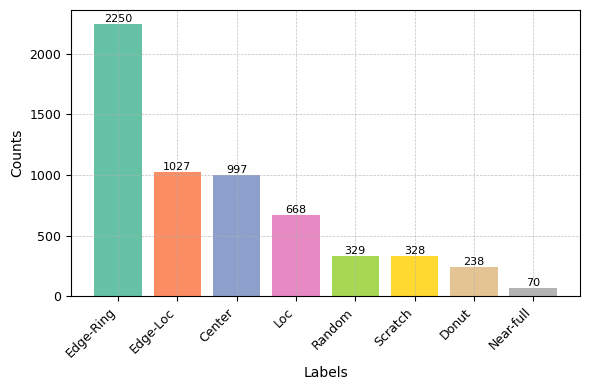

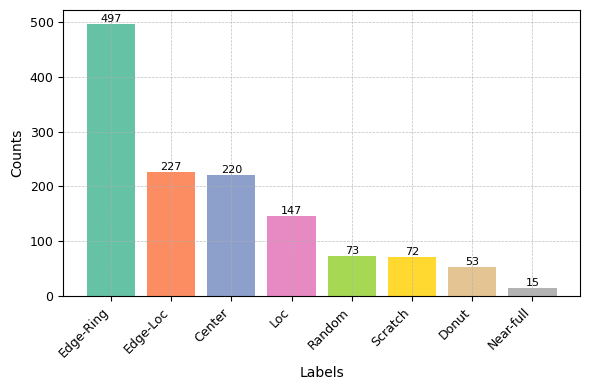

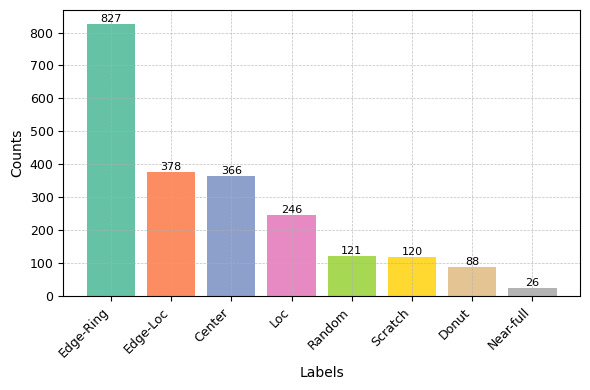

In [8]:
plot_label_distribution(train, label_col='labels', title='', save_path= cfg.output_dir+'wm811k_train_label_distribution.pdf', show=True)
plot_label_distribution(valid, label_col='labels', title='', save_path= cfg.output_dir+'wm811k_valid_label_distribution.pdf', show=True)
plot_label_distribution(test, label_col='labels', title='', save_path= cfg.output_dir+'wm811k_test_label_distribution.pdf', show=True)

In [9]:
# labels encoding
label2int = {'Center': 0, 'Donut': 1, 'Edge-Loc': 2, 'Edge-Ring': 3,
             'Loc': 4, 'Random': 5, 'Scratch': 6, 'Near-full': 7}
int2label = {v: k for k, v in label2int.items()}

# The class names are kept in `label_name` and `labels` is always derived from
# them, so rerunning this cell gives the same result.
for name, d in [("train", train), ("valid", valid), ("test", test)]:
    if "label_name" not in d:
        d["label_name"] = d["labels"]
    d["labels"] = d["label_name"].map(label2int)
    unmapped = d.loc[d["labels"].isna(), "label_name"].unique()
    assert len(unmapped) == 0, f"{name}: values not in label2int: {unmapped}"
    d["labels"] = d["labels"].astype(np.int64)
    print(name, np.sort(d["labels"].unique()))

train [0 1 2 3 4 5 6 7]
valid [0 1 2 3 4 5 6 7]
test [0 1 2 3 4 5 6 7]


## **6. Model training**

Every model in `CFG.models` is trained in turn with the same seed, splits and
preprocessing. The training transform is the validation transform: no
geometric augmentation is applied, which should be stated when the dispersion
of the predictions along the $D_4$ orbit is discussed.

For each model the run writes to `output_dir`:
`{model}_best.pth` (the checkpoint with the best validation AUC),
`{model}_oof_df.csv` (validation predictions) and, as its last step,
`{model}_done.json`. With `retrain = False` a model with a `_done.json` is
skipped, so after an interruption rerunning the cell resumes from the first
model not completed. `/kaggle/working` is cleared when the session ends:
save the version or download the checkpoints before that.

<class 'numpy.ndarray'>
(404, 404, 3)
<class 'numpy.ndarray'>
(404, 404, 3)


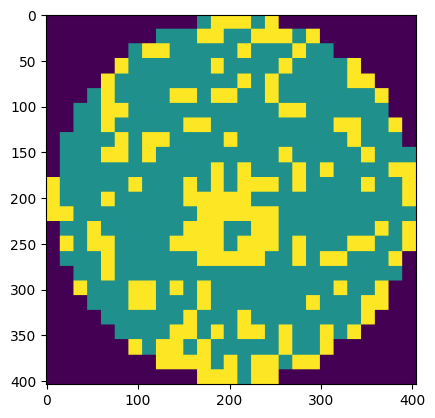

In [10]:
sample_image = cv2.imread(train.iloc[0]['image_id'])
print(type(sample_image))
print(sample_image.shape)
sample_image = cv2.cvtColor(sample_image, cv2.COLOR_BGR2RGB)
print(type(sample_image))
print(sample_image.shape)
plt.imshow(sample_image)

========== start: training tf_efficientnet_b0_ns ==========


model name: tf_efficientnet_b0_ns | target size: 8 | epochs: 25


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Epoch: [1][0/369] Data 0.355 (0.355) Elapsed 0m 2s (remain 12m 2s) Loss: 3.1207(3.1207)
Epoch: [1][100/369] Data 0.000 (0.004) Elapsed 0m 10s (remain 0m 27s) Loss: 0.5540(1.0439)
Epoch: [1][200/369] Data 0.000 (0.002) Elapsed 0m 18s (remain 0m 15s) Loss: 0.8302(0.8643)
Epoch: [1][300/369] Data 0.000 (0.001) Elapsed 0m 26s (remain 0m 6s) Loss: 0.5529(0.7610)
Epoch: [1][368/369] Data 0.000 (0.001) Elapsed 0m 32s (remain 0m 0s) Loss: 0.4396(0.7128)
EVAL: [0/82] Data 0.294 (0.294) Elapsed 0m 0s (remain 0m 28s) Loss: 0.3191(0.3191)


Epoch 1 - avg_train_loss: 0.7128  avg_val_loss: 0.3689  lr: 1.0e-04  time: 36s
Epoch 1 - Accuracy: 0.8650 AUC: 0.9818
Epoch 1 - Save Best Score: 0.9818 Model


...

EVAL: [81/82] Data 0.000 (0.014) Elapsed 0m 3s (remain 0m 0s) Loss: 0.0131(0.2898)
Epoch: [14][0/369] Data 0.254 (0.254) Elapsed 0m 0s (remain 2m 7s) Loss: 0.0048(0.0048)
Epoch: [14][100/369] Data 0.000 (0.003) Elapsed 0m 9s (remain 0m 25s) Loss: 0.0007(0.0062)
Epoch: [14][200/369] Data 0.000 (0.001) Elapsed 0m 18s (remain 0m 15s) Loss: 0.0010(0.0046)
Epoch: [14][300/369] Data 0.000 (0.001) Elapsed 0m 27s (remain 0m 6s) Loss: 0.0007(0.0040)
Epoch: [14][368/369] Data 0.000 (0.001) Elapsed 0m 34s (remain 0m 0s) Loss: 0.0009(0.0039)
EVAL: [0/82] Data 0.240 (0.240) Elapsed 0m 0s (remain 0m 22s) Loss: 0.0224(0.0224)


Epoch 14 - avg_train_loss: 0.0039  avg_val_loss: 0.2759  lr: 4.0e-06  time: 36s
Epoch 14 - Accuracy: 0.9264 AUC: 0.9935


EVAL: [81/82] Data 0.000 (0.012) Elapsed 0m 3s (remain 0m 0s) Loss: 0.0076(0.2759)
Epoch: [15][0/369] Data 0.225 (0.225) Elapsed 0m 0s (remain 1m 57s) Loss: 0.0015(0.0015)
Epoch: [15][100/369] Data 0.000 (0.002) Elapsed 0m 9s (remain 0m 25s) Loss: 0.0003(0.0039)
Epoch: [15][200/369] Data 0.000 (0.001) Elapsed 0m 18s (remain 0m 15s) Loss: 0.0631(0.0034)
Epoch: [15][300/369] Data 0.000 (0.001) Elapsed 0m 28s (remain 0m 6s) Loss: 0.0014(0.0037)
Epoch: [15][368/369] Data 0.000 (0.001) Elapsed 0m 34s (remain 0m 0s) Loss: 0.0003(0.0036)
EVAL: [0/82] Data 0.242 (0.242) Elapsed 0m 0s (remain 0m 22s) Loss: 0.0104(0.0104)


Epoch 15 - avg_train_loss: 0.0036  avg_val_loss: 0.2753  lr: 8.0e-07  time: 37s
Epoch 15 - Accuracy: 0.9279 AUC: 0.9936
***Max patience 3 reached - AUC: 0.9936***


EVAL: [81/82] Data 0.000 (0.013) Elapsed 0m 3s (remain 0m 0s) Loss: 0.0090(0.2753)


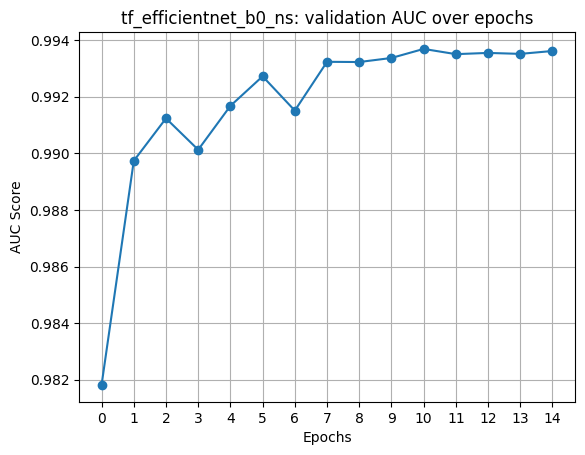

Score: 0.92408
========== CV ==========
Score: 0.92408
tf_efficientnet_b0_ns: best validation AUC 0.9937 at epoch 11 of 15
========== start: training resnext50_32x4d ==========


model name: resnext50_32x4d | target size: 8 | epochs: 25


model.safetensors:   0%|          | 0.00/100M [00:00<?, ?B/s]

Epoch: [1][0/369] Data 0.282 (0.282) Elapsed 0m 1s (remain 5m 8s) Loss: 2.0590(2.0590)
Epoch: [1][100/369] Data 0.000 (0.003) Elapsed 0m 30s (remain 1m 20s) Loss: 1.0729(1.5330)
Epoch: [1][200/369] Data 0.000 (0.002) Elapsed 0m 59s (remain 0m 49s) Loss: 1.1344(1.2642)
Epoch: [1][300/369] Data 0.000 (0.001) Elapsed 1m 27s (remain 0m 20s) Loss: 0.9629(1.0892)
Epoch: [1][368/369] Data 0.000 (0.001) Elapsed 1m 47s (remain 0m 0s) Loss: 0.9262(1.0154)
EVAL: [0/82] Data 0.243 (0.243) Elapsed 0m 0s (remain 0m 24s) Loss: 0.7816(0.7816)


Epoch 1 - avg_train_loss: 1.0154  avg_val_loss: 0.5214  lr: 1.0e-04  time: 113s
Epoch 1 - Accuracy: 0.8190 AUC: 0.9710
Epoch 1 - Save Best Score: 0.9710 Model


...

EVAL: [81/82] Data 0.000 (0.003) Elapsed 0m 7s (remain 0m 0s) Loss: 0.0073(0.2421)
Epoch: [11][0/369] Data 0.252 (0.252) Elapsed 0m 0s (remain 2m 18s) Loss: 0.0147(0.0147)
Epoch: [11][100/369] Data 0.000 (0.003) Elapsed 0m 29s (remain 1m 16s) Loss: 0.0854(0.0109)
Epoch: [11][200/369] Data 0.000 (0.001) Elapsed 0m 57s (remain 0m 48s) Loss: 0.0016(0.0097)
Epoch: [11][300/369] Data 0.000 (0.001) Elapsed 1m 26s (remain 0m 19s) Loss: 0.0068(0.0108)
Epoch: [11][368/369] Data 0.000 (0.001) Elapsed 1m 45s (remain 0m 0s) Loss: 0.0101(0.0121)
EVAL: [0/82] Data 0.264 (0.264) Elapsed 0m 0s (remain 0m 26s) Loss: 0.0282(0.0282)


Epoch 11 - avg_train_loss: 0.0121  avg_val_loss: 0.2746  lr: 2.0e-05  time: 112s
Epoch 11 - Accuracy: 0.9279 AUC: 0.9939


EVAL: [81/82] Data 0.000 (0.004) Elapsed 0m 7s (remain 0m 0s) Loss: 0.0255(0.2746)
Epoch: [12][0/369] Data 0.247 (0.247) Elapsed 0m 0s (remain 2m 19s) Loss: 0.0034(0.0034)
Epoch: [12][100/369] Data 0.000 (0.003) Elapsed 0m 29s (remain 1m 16s) Loss: 0.0071(0.0117)
Epoch: [12][200/369] Data 0.000 (0.001) Elapsed 0m 57s (remain 0m 48s) Loss: 0.0025(0.0102)
Epoch: [12][300/369] Data 0.000 (0.001) Elapsed 1m 26s (remain 0m 19s) Loss: 0.0032(0.0086)
Epoch: [12][368/369] Data 0.000 (0.001) Elapsed 1m 45s (remain 0m 0s) Loss: 0.0031(0.0083)
EVAL: [0/82] Data 0.256 (0.256) Elapsed 0m 0s (remain 0m 26s) Loss: 0.0270(0.0270)


Epoch 12 - avg_train_loss: 0.0083  avg_val_loss: 0.2644  lr: 2.0e-05  time: 112s
Epoch 12 - Accuracy: 0.9333 AUC: 0.9942
***Max patience 3 reached - AUC: 0.9942***


EVAL: [81/82] Data 0.000 (0.004) Elapsed 0m 7s (remain 0m 0s) Loss: 0.0097(0.2644)


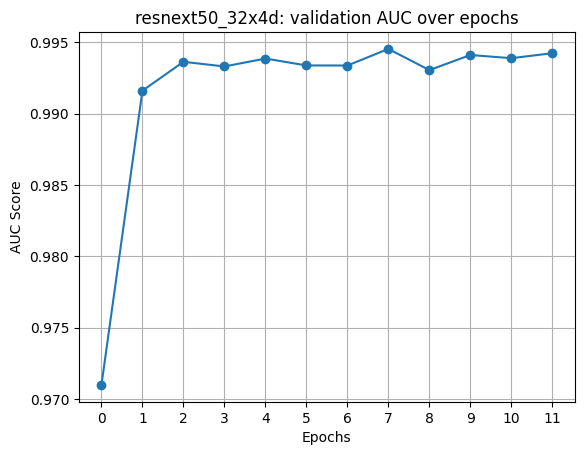

Score: 0.93328
========== CV ==========
Score: 0.93328
resnext50_32x4d: best validation AUC 0.9945 at epoch 8 of 12
========== start: training coat_tiny ==========


model name: coat_tiny | target size: 8 | epochs: 25


pytorch_model.bin:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Epoch: [1][0/369] Data 0.242 (0.242) Elapsed 0m 12s (remain 72m 27s) Loss: 2.1458(2.1458)
Epoch: [1][100/369] Data 0.000 (0.003) Elapsed 1m 2s (remain 2m 45s) Loss: 0.6911(0.9450)
Epoch: [1][200/369] Data 0.000 (0.001) Elapsed 1m 50s (remain 1m 32s) Loss: 0.3574(0.7148)
Epoch: [1][300/369] Data 0.000 (0.001) Elapsed 2m 39s (remain 0m 36s) Loss: 0.3903(0.5949)
Epoch: [1][368/369] Data 0.000 (0.001) Elapsed 3m 12s (remain 0m 0s) Loss: 0.1996(0.5410)
EVAL: [0/82] Data 0.267 (0.267) Elapsed 0m 0s (remain 0m 32s) Loss: 0.2291(0.2291)


Epoch 1 - avg_train_loss: 0.5410  avg_val_loss: 0.2540  lr: 1.0e-04  time: 208s
Epoch 1 - Accuracy: 0.9087 AUC: 0.9930
Epoch 1 - Save Best Score: 0.9930 Model


...

EVAL: [81/82] Data 0.000 (0.004) Elapsed 0m 11s (remain 0m 0s) Loss: 0.2399(0.1756)
Epoch: [7][0/369] Data 0.263 (0.263) Elapsed 0m 1s (remain 3m 6s) Loss: 0.0288(0.0288)
Epoch: [7][100/369] Data 0.000 (0.003) Elapsed 0m 49s (remain 2m 11s) Loss: 0.0435(0.0263)
Epoch: [7][200/369] Data 0.000 (0.001) Elapsed 1m 38s (remain 1m 22s) Loss: 0.0736(0.0394)
Epoch: [7][300/369] Data 0.000 (0.001) Elapsed 2m 27s (remain 0m 33s) Loss: 0.0675(0.0459)
Epoch: [7][368/369] Data 0.000 (0.001) Elapsed 3m 0s (remain 0m 0s) Loss: 0.1262(0.0448)
EVAL: [0/82] Data 0.279 (0.279) Elapsed 0m 0s (remain 0m 32s) Loss: 0.1083(0.1083)


Epoch 7 - avg_train_loss: 0.0448  avg_val_loss: 0.1758  lr: 1.0e-04  time: 191s
Epoch 7 - Accuracy: 0.9402 AUC: 0.9970


EVAL: [81/82] Data 0.000 (0.004) Elapsed 0m 11s (remain 0m 0s) Loss: 0.1120(0.1758)
Epoch: [8][0/369] Data 0.277 (0.277) Elapsed 0m 1s (remain 3m 14s) Loss: 0.0018(0.0018)
Epoch: [8][100/369] Data 0.000 (0.003) Elapsed 0m 49s (remain 2m 11s) Loss: 0.0125(0.0384)
Epoch: [8][200/369] Data 0.000 (0.002) Elapsed 1m 38s (remain 1m 22s) Loss: 0.3122(0.0432)
Epoch: [8][300/369] Data 0.000 (0.001) Elapsed 2m 27s (remain 0m 33s) Loss: 0.0042(0.0371)
Epoch: [8][368/369] Data 0.000 (0.001) Elapsed 3m 0s (remain 0m 0s) Loss: 0.4369(0.0477)
EVAL: [0/82] Data 0.301 (0.301) Elapsed 0m 0s (remain 0m 34s) Loss: 0.2873(0.2873)


Epoch 8 - avg_train_loss: 0.0477  avg_val_loss: 0.3216  lr: 2.0e-05  time: 191s
Epoch 8 - Accuracy: 0.9110 AUC: 0.9930
***Max patience 3 reached - AUC: 0.9930***


EVAL: [81/82] Data 0.000 (0.004) Elapsed 0m 11s (remain 0m 0s) Loss: 0.1491(0.3216)


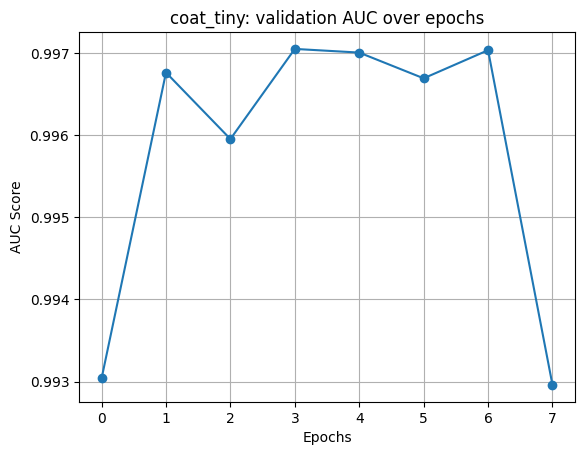

Score: 0.93558
========== CV ==========
Score: 0.93558
coat_tiny: best validation AUC 0.9971 at epoch 4 of 8


In [11]:
for name in cfg.models:
    c = cfg_for(name)
    if os.path.isfile(done_file(name, c)) and not cfg.retrain:
        print(f"{name}: run already completed, skipped")
        continue
    print(f"model name: {c.model_name} | target size: {c.target_size} | epochs: {c.epochs}")
    main(c, train, valid)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## **7. Test Evaluation**

Each completed model is reloaded from its best checkpoint and evaluated on the
test split. The per-class AUC is computed from the predicted probabilities.

In [12]:
# Setup e test loader
#--------------------------------------------------------------------------------------
test_dataset = TrainDataset(test, transform=get_transforms(data='valid', cfg=cfg))
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers, pin_memory=True)
y_true = test['labels'].to_numpy()

In [13]:
# Inference and metrics for every completed model
#---------------------------------------------------------------------------------
TEST_PROBS, summary_rows, auc_by_class = {}, [], {}

for name in cfg.models:
    c = cfg_for(name)
    if not os.path.isfile(done_file(name, c)):
        print(f"{name}: training not completed, skipped")
        continue

    model = Model_type(name, pretrained=False, cfg=c).to(device)
    state = torch.load(c.output_dir + f'{name}_best.pth', map_location=device, weights_only=False)
    model.load_state_dict(state['model'], strict=True)
    model.eval()

    probs = []
    with torch.no_grad():
        for images, _ in tqdm(test_loader, total=len(test_loader), desc=name):
            probs.append(model(images.to(device)).softmax(dim=1).cpu().numpy())
    probs = np.concatenate(probs)
    y_pred = probs.argmax(axis=1)
    TEST_PROBS[name] = probs

    summary_rows.append({'model': name,
                         'accuracy': accuracy_score(y_true, y_pred),
                         'macro_recall': recall_score(y_true, y_pred, average='macro'),
                         'macro_f1': f1_score(y_true, y_pred, average='macro'),
                         'auc_ovr_macro': roc_auc_score(y_true, probs, multi_class='ovr', average='macro')})
    auc_by_class[name] = {int2label[k]: v for k, v in roc_auc_per_class(y_true, probs).items()}

    del model, state
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

summary = pd.DataFrame(summary_rows).set_index('model')
summary.to_csv(cfg.output_dir + 'test_summary.csv')
display(summary.round(4))

print("ROC AUC for each class (one-vs-rest, from probabilities):")
display(pd.DataFrame(auc_by_class).round(3))

tf_efficientnet_b0_ns:   0%|          | 0/136 [00:00<?, ?it/s]

resnext50_32x4d:   0%|          | 0/136 [00:00<?, ?it/s]

coat_tiny:   0%|          | 0/136 [00:00<?, ?it/s]

,accuracy,macro_recall,macro_f1,auc_ovr_macro
model,,,,
tf_efficientnet_b0_ns,0.9125,0.8731,0.8746,0.9931
resnext50_32x4d,0.9236,0.9015,0.8978,0.9928
coat_tiny,0.9309,0.9032,0.9028,0.9959


ROC AUC for each class (one-vs-rest, from probabilities):


,tf_efficientnet_b0_ns,resnext50_32x4d,coat_tiny
Center,0.997,0.997,0.999
Donut,0.997,0.994,0.998
Edge-Loc,0.990,0.983,0.994
Edge-Ring,0.999,0.999,0.999
Loc,0.972,0.977,0.984
Random,0.998,0.997,0.996
Scratch,0.991,0.995,0.997
Near-full,1.000,1.000,1.000
